In [1]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
import plotly.express as px
from datetime import datetime

In [2]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
play_store_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\Play Store Data.csv")

In [4]:
play_store_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
reviews_df = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\Google_Play_Store_Internship_Project\Data\User Reviews.csv")
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [6]:
#data cleaning
play_store_df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [7]:
reviews_df.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [8]:
play_store_df = play_store_df.drop_duplicates(subset="App")
play_store_df.shape

(9660, 13)

In [9]:
play_store_df.isnull().sum()

App                  0
Category             0
Rating            1463
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [10]:
#data transformation
play_store_df["Rating"] = play_store_df["Rating"].fillna(
    play_store_df["Rating"].median()
)

In [11]:
play_store_df["Type"] = play_store_df["Type"].fillna(
    play_store_df["Type"].mode()[0]
)

In [12]:
play_store_df["Current Ver"] = play_store_df["Current Ver"].fillna(
    play_store_df["Current Ver"].mode()[0]
)
play_store_df["Android Ver"] = play_store_df["Android Ver"].fillna(
    play_store_df["Android Ver"].mode()[0]
)
play_store_df["Content Rating"] = play_store_df["Content Rating"].fillna(
    play_store_df["Content Rating"].mode()[0]
)
play_store_df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [13]:
play_store_df["Installs_Num"] = (
    play_store_df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

play_store_df["Installs_Num"] = pd.to_numeric(
    play_store_df["Installs_Num"],
    errors="coerce"
)
play_store_df[["Installs", "Installs_Num"]].head()

,Installs,Installs_Num
0,"10,000+",10000.0
1,"500,000+",500000.0
2,"5,000,000+",5000000.0
3,"50,000,000+",50000000.0
4,"100,000+",100000.0


In [14]:
play_store_df["Reviews"] = pd.to_numeric(
    play_store_df["Reviews"],
    errors="coerce"
)
play_store_df["Reviews"].dtype

dtype('float64')

In [15]:
play_store_df = play_store_df[
    play_store_df["Size"] != "Varies with device"
]
play_store_df["Size"].head()

0     19M
1     14M
2    8.7M
3     25M
4    2.8M
Name: Size, dtype: str

In [16]:
play_store_df["Size"] = play_store_df["Size"].replace(
    "M", "", regex=True
)

play_store_df["Size"] = play_store_df["Size"].replace(
    "k", "", regex=True
)
play_store_df["Size"] = pd.to_numeric(
    play_store_df["Size"],
    errors="coerce"
)
play_store_df["Size"].head()

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64

In [17]:
#merge the files
merged_df = pd.merge(
    play_store_df,
    reviews_df,
    on="App",
    how="inner"
)
merged_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0,NaN,NaN,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,500000.0,I love colors inspyering,Positive,0.500,0.600000


In [18]:
#filtering
filtered_df = merged_df[
    merged_df["Rating"] >= 4.2
]
filtered_df = filtered_df[
    ~filtered_df["App"].str.contains(r"\d", regex=True, na=False)
]
filtered_df = filtered_df[
    filtered_df["Category"].str.startswith(("T", "P"), na=False)
]
filtered_df = filtered_df[
    filtered_df["Reviews"] > 1000
]
filtered_df.shape

(4398, 18)

In [19]:
filtered_df = filtered_df[
    (filtered_df["Size"] >= 20) &
    (filtered_df["Size"] <= 80)
]
filtered_df.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
29396,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"I never write reviews, deserves good review! I...",Positive,0.350463,0.688889
29397,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,So far good. I ordered free pictures I also fr...,Positive,0.420833,0.650000
29398,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,Reply devs: I already reached support team.. w...,Negative,-0.333333,0.333333
29399,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,Love app! For anyone reading this....... If it...,Positive,0.375000,0.377778
29400,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,This awesome easy I got photos fast! Pictures ...,Positive,0.581944,0.811111
29401,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"I love app. It works well, month I get 85 pict...",Positive,0.312000,0.468000
29402,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"Now telling I owe 2,99 well I'm going wait . g...",Neutral,0.000000,0.000000
29403,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"Order see quality first order never came, e-ma...",Positive,0.625000,0.666667
29404,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"You choose photo, enlarge, rotate crop photo. ...",Positive,0.416667,0.711111
29405,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"At first I little worried sounded good true., ...",Positive,0.335417,0.580556


In [20]:
filtered_df = filtered_df.drop_duplicates(subset="App")
filtered_df.shape

(24, 18)

In [21]:
filtered_df["Category"].value_counts()

Category
PHOTOGRAPHY         6
TRAVEL_AND_LOCAL    6
PERSONALIZATION     5
PRODUCTIVITY        4
PARENTING           2
TOOLS               1
Name: count, dtype: int64

In [22]:
translation_dict = {
    "TRAVEL_AND_LOCAL": "Voyage et Local",
    "PRODUCTIVITY": "Productividad",
    "PHOTOGRAPHY": "写真"
}

In [23]:
filtered_df["Display_Category"] = (
    filtered_df["Category"].replace(translation_dict)
)

In [24]:
filtered_df[
    ["Category", "Display_Category"]
].drop_duplicates()

,Category,Display_Category
29396,PHOTOGRAPHY,写真
32276,TRAVEL_AND_LOCAL,Voyage et Local
34621,TOOLS,TOOLS
34901,PERSONALIZATION,PERSONALIZATION
36221,PRODUCTIVITY,Productividad
37141,PARENTING,PARENTING


In [25]:
filtered_df.shape

(24, 19)

In [26]:
translation_dict = {
    "TRAVEL_AND_LOCAL": "Voyage et Local",
    "PRODUCTIVITY": "Productividad",
    "PHOTOGRAPHY": "写真"
}
filtered_df["Display_Category"] = filtered_df["Category"].replace(
    translation_dict
)

In [27]:
filtered_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Installs_Num,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Display_Category
29396,FreePrints – Free Photos Delivered,PHOTOGRAPHY,4.8,109500.0,37.0,"1,000,000+",Free,0,Everyone,Photography,"August 2, 2018",2.18.2,4.1 and up,1000000.0,"I never write reviews, deserves good review! I...",Positive,0.350463,0.688889,写真
29516,"Face Filter, Selfie Editor - Sweet Camera",PHOTOGRAPHY,4.7,142634.0,22.0,"10,000,000+",Free,0,Everyone,Photography,"July 6, 2018",1.5.1,4.4 and up,10000000.0,NaN,NaN,NaN,NaN,写真
29676,BeautyPlus - Easy Photo Editor & Selfie Camera,PHOTOGRAPHY,4.4,3158047.0,53.0,"100,000,000+",Free,0,Everyone,Photography,"July 31, 2018",6.9.031,4.1 and up,100000000.0,NaN,NaN,NaN,NaN,写真
29876,"Candy selfie - photo editor, live filter camera",PHOTOGRAPHY,4.4,53421.0,26.0,"10,000,000+",Free,0,Everyone,Photography,"August 6, 2018",2.74.685,4.0.3 and up,10000000.0,Best ever Camera,Positive,1.000000,0.300000,写真
30796,EyeEm - Camera & Photo Filter,PHOTOGRAPHY,4.2,215343.0,44.0,"10,000,000+",Free,0,Everyone,Photography,"July 14, 2018",6.4.3,4.0.3 and up,10000000.0,Love app. Have sold photos. But would great di...,Positive,0.375000,0.393750,写真


In [28]:
filtered_df[
    ["Category", "Display_Category"]
].drop_duplicates()

,Category,Display_Category
29396,PHOTOGRAPHY,写真
32276,TRAVEL_AND_LOCAL,Voyage et Local
34621,TOOLS,TOOLS
34901,PERSONALIZATION,PERSONALIZATION
36221,PRODUCTIVITY,Productividad
37141,PARENTING,PARENTING


In [29]:
filtered_df["Last Updated"] = pd.to_datetime(
    filtered_df["Last Updated"]
)
filtered_df["Last Updated"].head()

29396   2018-08-02
29516   2018-07-06
29676   2018-07-31
29876   2018-08-06
30796   2018-07-14
Name: Last Updated, dtype: datetime64[us]

In [30]:
filtered_df["Month"] = filtered_df["Last Updated"].dt.to_period("M")
filtered_df[
    ["Last Updated", "Month"]
].head(10)

,Last Updated,Month
29396,2018-08-02,2018-08
29516,2018-07-06,2018-07
29676,2018-07-31,2018-07
29876,2018-08-06,2018-08
30796,2018-07-14,2018-07
30916,2017-06-23,2017-06
32276,2018-07-16,2018-07
32396,2018-08-02,2018-08
32796,2018-08-05,2018-08
32836,2018-07-24,2018-07


In [31]:
monthly_installs = (
    filtered_df.groupby(
        ["Month", "Display_Category"]
    )["Installs_Num"]
    .sum()
    .reset_index()
)

In [32]:
monthly_installs["Month"] = monthly_installs["Month"].astype(str)
monthly_installs.head()

,Month,Display_Category,Installs_Num
0,2016-12,PERSONALIZATION,1000000.0
1,2017-06,写真,10000000.0
2,2017-09,PERSONALIZATION,1000000.0
3,2018-04,Voyage et Local,5000000.0
4,2018-06,Productividad,10000000.0


In [33]:
monthly_installs = monthly_installs.sort_values(
    by=["Display_Category", "Month"]
)

In [34]:
monthly_installs["Cumulative_Installs"] = (
    monthly_installs.groupby("Display_Category")["Installs_Num"]
    .cumsum()
)

In [35]:
monthly_installs

,Month,Display_Category,Installs_Num,Cumulative_Installs
5,2018-07,PARENTING,600000.0,600000.0
0,2016-12,PERSONALIZATION,1000000.0,1000000.0
2,2017-09,PERSONALIZATION,1000000.0,2000000.0
6,2018-07,PERSONALIZATION,11500000.0,13500000.0
4,2018-06,Productividad,10000000.0,10000000.0
7,2018-07,Productividad,11000000.0,21000000.0
10,2018-08,Productividad,500000000.0,521000000.0
11,2018-08,TOOLS,50000000.0,50000000.0
3,2018-04,Voyage et Local,5000000.0,5000000.0
8,2018-07,Voyage et Local,2000000.0,7000000.0


In [36]:
monthly_installs["Growth_Percentage"] = (
    monthly_installs.groupby("Display_Category")["Installs_Num"]
    .pct_change() * 100
)

In [37]:
monthly_installs

,Month,Display_Category,Installs_Num,Cumulative_Installs,Growth_Percentage
5,2018-07,PARENTING,600000.0,600000.0,NaN
0,2016-12,PERSONALIZATION,1000000.0,1000000.0,NaN
2,2017-09,PERSONALIZATION,1000000.0,2000000.0,0.000000
6,2018-07,PERSONALIZATION,11500000.0,13500000.0,1050.000000
4,2018-06,Productividad,10000000.0,10000000.0,NaN
7,2018-07,Productividad,11000000.0,21000000.0,10.000000
10,2018-08,Productividad,500000000.0,521000000.0,4445.454545
11,2018-08,TOOLS,50000000.0,50000000.0,NaN
3,2018-04,Voyage et Local,5000000.0,5000000.0,NaN
8,2018-07,Voyage et Local,2000000.0,7000000.0,-60.000000


In [38]:
monthly_installs["Significant_Growth"] = (
    monthly_installs["Growth_Percentage"] > 25
)
monthly_installs

,Month,Display_Category,Installs_Num,Cumulative_Installs,Growth_Percentage,Significant_Growth
5,2018-07,PARENTING,600000.0,600000.0,NaN,False
0,2016-12,PERSONALIZATION,1000000.0,1000000.0,NaN,False
2,2017-09,PERSONALIZATION,1000000.0,2000000.0,0.000000,False
6,2018-07,PERSONALIZATION,11500000.0,13500000.0,1050.000000,True
4,2018-06,Productividad,10000000.0,10000000.0,NaN,False
7,2018-07,Productividad,11000000.0,21000000.0,10.000000,False
10,2018-08,Productividad,500000000.0,521000000.0,4445.454545,True
11,2018-08,TOOLS,50000000.0,50000000.0,NaN,False
3,2018-04,Voyage et Local,5000000.0,5000000.0,NaN,False
8,2018-07,Voyage et Local,2000000.0,7000000.0,-60.000000,False


In [39]:
monthly_installs["Significant_Growth"].value_counts()

Significant_Growth
False    10
True      4
Name: count, dtype: int64

In [40]:
fig = px.area(
    monthly_installs,
    x="Month",
    y="Cumulative_Installs",
    color="Display_Category",
    title="Cumulative Installs Over Time by App Category"
)

In [41]:
for _, row in monthly_installs[
    monthly_installs["Significant_Growth"]
].iterrows():

    fig.add_annotation(
        x=row["Month"],
        y=row["Cumulative_Installs"],
        text="▲ >25%",
        showarrow=True,
        arrowhead=2,
        bgcolor="yellow"
    )

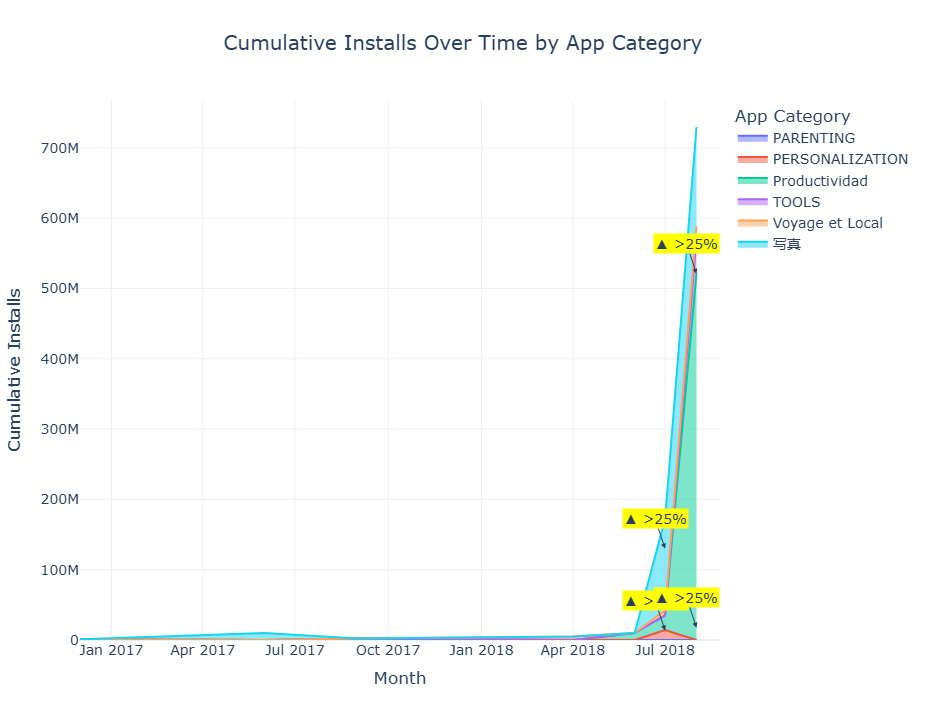

In [42]:
fig.update_layout(
    title={
        "text":"Cumulative Installs Over Time by App Category",
        "x":0.5
    },
    xaxis_title="Month",
    yaxis_title="Cumulative Installs",
    legend_title="App Category",
    template="plotly_white",
    hovermode="x unified",
    font=dict(size=14)
)
fig.update_layout(
    width=1200,
    height=700
)

In [43]:
from datetime import datetime

current_hour = datetime.now().hour

if 16 <= current_hour < 18:
    fig.show()
else:
    print("This graph is available only between 4 PM IST and 6 PM IST.")

This graph is available only between 4 PM IST and 6 PM IST.


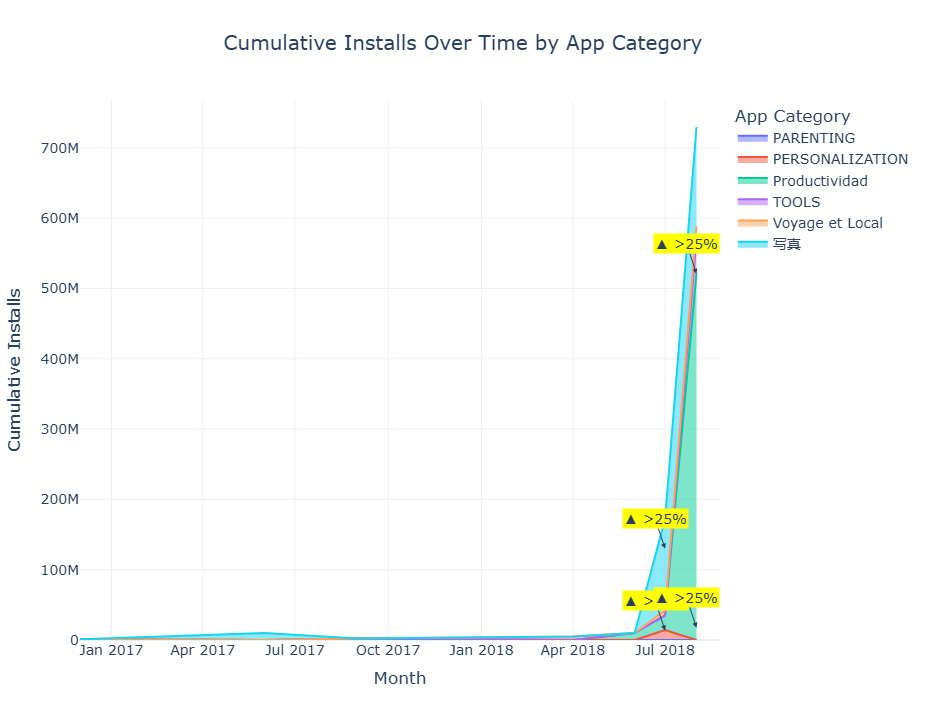

In [44]:
current_hour = 17
if 16 <= current_hour < 18:
    fig.show()
else:
    print("This graph is available only between 4 PM IST and 6 PM IST.")